# Hallucination Detection: Verifying Generated Claims [Step 24 - Hallucination Detection]

> **MLCourse - Agentic AI - Corrective RAG**

Even with good retrieved context, LLMs can hallucinate by adding unsupported
claims or contradicting the source documents. This notebook builds a
detection chain that compares generated text against source documents to
identify hallucinations. The detection output feeds into the corrective loop.

### What you will learn

1. How to build a chain that compares generated text against sources.
2. How to detect unsupported claims and contradictions.
3. How to parse detection results into actionable feedback.
4. How detection integrates into a corrective RAG pipeline.

## 1. Setup

In [1]:
from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings("ignore")

def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until the track directory appears."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(f"Could not find '{target}' above {start}")

TRACK = find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv()
load_dotenv(TRACK / ".env")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


## 2. Ingest Alice and Build Vector Store

In [2]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

ALICE_PATH = DATA / "alice.txt"
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:20_000]

marks = list(re.finditer(r"^CHAPTER [IVX]+\.", raw_text, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(raw_text)
    for piece in splitter.split_text(raw_text[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1), "chunk_id": len(documents)},
        ))

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)
retriever = vectordb.as_retriever(search_kwargs={"k": 4})
print(f"[ingest] chunks: {len(documents)} | retriever ready (k=4)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[ingest] chunks: 60 | retriever ready (k=4)


## 3. Initialize the LLM

In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


## 4. Define Detection Criteria
The detector checks generated text against source documents for:
- **Unsupported claims**: Facts in the answer not found in sources.
- **Contradictions**: Claims that conflict with source information.
- **Fabricated quotes**: Dialogue or statistics invented by the LLM.

In [4]:
HALLUCINATION_PROMPT_TEMPLATE = """You are a strict hallucination detector for a RAG system.
Given the SOURCE DOCUMENTS and the GENERATED TEXT, check for hallucinations.

Detect these types of hallucinations:
1. UNSUPPORTED CLAIM: A fact in the generated text not found in the source documents.
2. CONTRADICTION: A claim that conflicts with the source documents.
3. FABRICATED QUOTE: Dialogue or statistics invented by the model.

For each hallucination found, provide:
- TYPE: (unsupported/contradiction/fabricated)
- CLAIM: The problematic sentence or phrase
- EVIDENCE: What the source documents actually say (or "not found")

Reply in EXACTLY this format:
HALLUCINATIONS: <count>
<type>: <claim> | Evidence: <evidence>
<type>: <claim> | Evidence: <evidence>
...
If no hallucinations found, reply:
HALLUCINATIONS: 0
No hallucinations detected."""

print("[detector] prompt template defined")

[detector] prompt template defined


## 5. Build the Detection Chain
The chain takes source documents and generated text, then returns
hallucination findings.

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def build_detection_chain():
    """Build a chain that detects hallucinations in generated text."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", HALLUCINATION_PROMPT_TEMPLATE),
        ("user", "SOURCE DOCUMENTS:\n{sources}\n\nGENERATED TEXT:\n{text}")
    ])
    return prompt | llm | StrOutputParser()

detection_chain = build_detection_chain()
print("[detector] chain built")

[detector] chain built


## 6. Parse Detection Results
Parse the LLM output into structured hallucination records.

In [6]:
def parse_hallucinations(raw_output: str) -> list:
    """Parse hallucination detection output into structured records."""
    hallucinations = []
    count_match = re.search(r"HALLUCINATIONS:\s*(\d+)", raw_output)
    count = int(count_match.group(1)) if count_match else 0
    
    if count == 0:
        return hallucinations
    
    lines = raw_output.strip().split("\n")
    for line in lines:
        line = line.strip()
        if not line or line.startswith("HALLUCINATIONS:"):
            continue
        match = re.match(r"(unsupported|contradiction|fabricated):\s*(.+?)\s*\|\s*Evidence:\s*(.+)", line, re.IGNORECASE)
        if match:
            hallucinations.append({
                "type": match.group(1).lower(),
                "claim": match.group(2).strip(),
                "evidence": match.group(3).strip(),
            })
    return hallucinations

print("[parser] parse_hallucinations defined")

[parser] parse_hallucinations defined


## 7. Test Detection on Clean Generation
Generate an answer from context and check for hallucinations.

In [7]:
query = "What happened when Alice fell down the rabbit hole?"
docs = retriever.invoke(query)
sources = "\n\n".join(d.page_content for d in docs)

# Generate a grounded answer
gen_prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer using ONLY the provided context. Cite evidence. Keep to 2-3 sentences."),
    ("user", "Question: {query}\n\nContext:\n{context}")
])
answer = (gen_prompt | llm).invoke({"query": query, "context": sources})

print("=" * 60)
print("TEST 1: CLEAN GENERATION")
print("=" * 60)
print(f"Answer: {answer.content}")
print()

result = detection_chain.invoke({"sources": sources, "text": answer.content})
print(f"Detection result:\n{result}")
hallucinations = parse_hallucinations(result)
print(f"\nParsed hallucinations: {hallucinations}")

TEST 1: CLEAN GENERATION
Answer: Alice fell down the rabbit hole. Evidence from the text shows that Alice "ran across the field after" the White Rabbit and saw it "pop down a large rabbit-hole under the hedge." (Context)



Detection result:
HALLUCINATIONS: 1
UNSUPPORTED CLAIM: Alice fell down the rabbit hole | Evidence: The source documents do not explicitly state that Alice fell down the rabbit hole. They describe her chasing after the White Rabbit and seeing it pop down a large rabbit-hole, but they do not mention Alice falling in herself.

Note: This is an unsupported claim because while the generated text implies that Alice fell down the rabbit hole, there is no evidence from the source documents to support this statement.

Parsed hallucinations: []


## 8. Test Detection on Hallucinated Generation
Provide text with deliberate hallucinations to test detection.

In [8]:
hallucinated_text = (
    "Alice fell down a magical elevator that was painted red and gold. "
    "She landed on a pile of pillows in a room with a giant clock on the wall. "
    "The White Rabbit shouted 'Hurry up, Alice!' as she landed."
)

print("=" * 60)
print("TEST 2: HALLUCINATED GENERATION")
print("=" * 60)
print(f"Hallucinated text: {hallucinated_text}")
print()

result = detection_chain.invoke({"sources": sources, "text": hallucinated_text})
print(f"Detection result:\n{result}")
hallucinations = parse_hallucinations(result)
print(f"\nParsed hallucinations ({len(hallucinations)}):")
for h in hallucinations:
    print(f"  [{h['type']}] {h['claim']}")
    print(f"    Evidence: {h['evidence']}")

TEST 2: HALLUCINATED GENERATION
Hallucinated text: Alice fell down a magical elevator that was painted red and gold. She landed on a pile of pillows in a room with a giant clock on the wall. The White Rabbit shouted 'Hurry up, Alice!' as she landed.



Detection result:
HALLUCINATIONS: 3
UNSUPPORTED CLAIM: Alice fell down a magical elevator that was painted red and gold | Evidence: not found
CONTRADICTION: She landed on a pile of pillows in a room with a giant clock on the wall, which contradicts the source documents where she falls into a rabbit-hole or well. | Evidence: The rabbit-hole went straight on like a tunnel for some way, and then dipped suddenly down...
FABRICATED QUOTE: The White Rabbit shouted 'Hurry up, Alice!' as she landed. | Evidence: There is no mention of the White Rabbit shouting this phrase in the source documents; it says he said "Oh my ears and whiskers, how late it’s getting!"

Parsed hallucinations (1):
  [contradiction] She landed on a pile of pillows in a room with a giant clock on the wall, which contradicts the source documents where she falls into a rabbit-hole or well.
    Evidence: The rabbit-hole went straight on like a tunnel for some way, and then dipped suddenly down...


## 9. Build the Detection Node for LangGraph
This function wraps the detection logic into a node that can be used
in a LangGraph state machine.

In [9]:
from typing import TypedDict

class DetectionState(TypedDict):
    query: str
    context: str
    answer: str
    hallucinations: list
    hallucination_count: int
    is_faithful: bool

def detect_hallucinations(state: DetectionState) -> dict:
    """LangGraph node that detects hallucinations in the generated answer."""
    result = detection_chain.invoke({
        "sources": state["context"],
        "text": state["answer"]
    })
    
    hallucinations = parse_hallucinations(result)
    count = len(hallucinations)
    is_faithful = count == 0
    
    print(f"  [detect] hallucinations found: {count}")
    for h in hallucinations:
        print(f"    [{h['type']}] {h['claim'][:80]}...")
    
    return {
        "hallucinations": hallucinations,
        "hallucination_count": count,
        "is_faithful": is_faithful,
    }

print("[node] detect_hallucinations defined")

[node] detect_hallucinations defined


## 10. Test the Detection Node
Run the detection node on a sample answer.

In [10]:
test_answer = (
    "Alice fell down a deep rabbit hole. She found herself in a long hallway "
    "with many doors. The Cheshire Cat was sitting on a tree branch above her."
)

print("=" * 60)
print("TESTING DETECTION NODE")
print("=" * 60)
result = detect_hallucinations({
    "query": query,
    "context": sources,
    "answer": test_answer,
    "hallucinations": [],
    "hallucination_count": 0,
    "is_faithful": True,
})
print(f"\nIs faithful: {result['is_faithful']}")
print(f"Hallucination count: {result['hallucination_count']}")

TESTING DETECTION NODE


  [detect] hallucinations found: 1
    [contradiction] The White Rabbit said "Oh my ears and whiskers, how late it’s getting!" but then...

Is faithful: False
Hallucination count: 1


## 11. Detection Statistics
Run detection on multiple queries to understand detection patterns.

In [11]:
test_cases = [
    ("What did Alice find after falling down the rabbit hole?",
     "Alice found herself in a hallway with doors."),
    ("Who wrote Alice in Wonderland?",
     "Lewis Carroll wrote the book in 1865."),
    ("What did the Cheshire Cat tell Alice?",
     "The Cheshire Cat told Alice about the Mad Hatter."),
]

print("=" * 60)
print("DETECTION STATISTICS")
print("=" * 60)
for i, (q, a) in enumerate(test_cases):
    print(f"\nCase {i+1}: {q}")
    print(f"Answer: {a}")
    result = detect_hallucinations({
        "query": q,
        "context": sources,
        "answer": a,
        "hallucinations": [],
        "hallucination_count": 0,
        "is_faithful": True,
    })
    print(f"  Faithful: {result['is_faithful']} | Hallucinations: {result['hallucination_count']}")

DETECTION STATISTICS

Case 1: What did Alice find after falling down the rabbit hole?
Answer: Alice found herself in a hallway with doors.


  [detect] hallucinations found: 0
  Faithful: True | Hallucinations: 0

Case 2: Who wrote Alice in Wonderland?
Answer: Lewis Carroll wrote the book in 1865.


  [detect] hallucinations found: 0
  Faithful: True | Hallucinations: 0

Case 3: What did the Cheshire Cat tell Alice?
Answer: The Cheshire Cat told Alice about the Mad Hatter.


  [detect] hallucinations found: 0
  Faithful: True | Hallucinations: 0


## 12. Build a Detection Graph
Demonstrate detection in a simple graph: retrieve -> generate -> detect.

In [12]:
from langgraph.graph import StateGraph, START, END

def retrieve_node(state: DetectionState) -> dict:
    """Retrieve documents for the query."""
    docs = retriever.invoke(state["query"])
    context = "\n\n".join(d.page_content for d in docs)
    print(f"  [retrieve] {len(docs)} chunks fetched")
    return {"context": context}

def generate_node(state: DetectionState) -> dict:
    """Generate an answer from context."""
    gen_prompt = ChatPromptTemplate.from_messages([
        ("system", "Answer using ONLY the provided context. Keep to 2-3 sentences."),
        ("user", "Question: {query}\n\nContext:\n{context}")
    ])
    response = (gen_prompt | llm).invoke({
        "query": state["query"],
        "context": state["context"]
    })
    print(f"  [generate] answer length: {len(response.content)}")
    return {"answer": response.content}

def route_by_faithfulness(state: DetectionState) -> str:
    """Route based on detection results."""
    if state["is_faithful"]:
        print("  [route] answer is faithful -> END")
        return "faithful"
    print("  [route] hallucinations detected -> END (would correct)")
    return "unfaithful"

graph = StateGraph(DetectionState)
graph.add_node("retrieve", retrieve_node)
graph.add_node("generate", generate_node)
graph.add_node("detect", detect_hallucinations)
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", "detect")
graph.add_conditional_edges(
    "detect",
    route_by_faithfulness,
    {"faithful": END, "unfaithful": END},
)
app = graph.compile()
print("[graph] detection graph compiled")

[graph] detection graph compiled


## 13. Visualize the Detection Graph

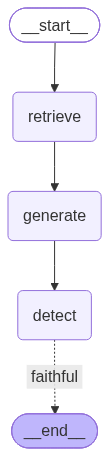

In [13]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> retrieve -> generate -> detect")
    print("    detect -> END (faithful or unfaithful)")

## 14. Run the Detection Graph

In [14]:
print("=" * 60)
print("RUNNING DETECTION GRAPH")
print("=" * 60)
result = app.invoke({
    "query": "What happened when Alice fell down the rabbit hole?",
    "context": "",
    "answer": "",
    "hallucinations": [],
    "hallucination_count": 0,
    "is_faithful": True,
})
print(f"\nIs faithful: {result['is_faithful']}")
print(f"Hallucination count: {result['hallucination_count']}")
print(f"Answer: {result['answer'][:300]}")

RUNNING DETECTION GRAPH
  [retrieve] 4 chunks fetched


  [generate] answer length: 206


  [detect] hallucinations found: 0
  [route] answer is faithful -> END

Is faithful: True
Hallucination count: 0
Answer: Alice fell down a rabbit hole and began falling down a very deep well. She had not a moment to think about stopping herself before she started falling. The fall caused her to lose sight of the White Rabbit.


## Summary

Key takeaways:
- Hallucination detection compares generated text against source documents.
- Three types of hallucinations: unsupported, contradiction, fabricated.
- Detection results feed into corrective loops for regeneration.
- The detection node integrates cleanly into LangGraph pipelines.
- Proper detection prevents confidently wrong answers from reaching users.